In [1]:
# pour CS : https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html
# pour Régression : https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html

# récupérer codes pour early stopping en régression
# https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_early_stopping.html

# stochastic gradient ?
# https://scikit-learn.org/stable/modules/sgd.html

On récupère le code : https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_early_stopping.html

In [4]:
import time

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

data = fetch_california_housing()
X, y = data.data[:600], data.target[:600]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training and Comparison
Two GradientBoostingRegressor models are trained: one with and another without early stopping. The purpose is to compare their performance. It also calculates the training time and the n_estimators_ used by both models.

In [6]:
params = dict(n_estimators=1000, max_depth=5, learning_rate=0.1, random_state=42)

gbm_full = GradientBoostingRegressor(**params)
gbm_early_stopping = GradientBoostingRegressor(
    **params,
    validation_fraction=0.1,
    n_iter_no_change=10,
)

start_time = time.time()
gbm_full.fit(X_train, y_train)
training_time_full = time.time() - start_time
n_estimators_full = gbm_full.n_estimators_

start_time = time.time()
gbm_early_stopping.fit(X_train, y_train)
training_time_early_stopping = time.time() - start_time
estimators_early_stopping = gbm_early_stopping.n_estimators_

## Error Calculation
The code calculates the mean_squared_error for both training and validation datasets for the models trained in the previous section. It computes the errors for each boosting iteration. The purpose is to assess the performance and convergence of the models.

In [7]:
train_errors_without = []
val_errors_without = []

train_errors_with = []
val_errors_with = []

for i, (train_pred, val_pred) in enumerate(
    zip(
        gbm_full.staged_predict(X_train),
        gbm_full.staged_predict(X_val),
    )
):
    train_errors_without.append(mean_squared_error(y_train, train_pred))
    val_errors_without.append(mean_squared_error(y_val, val_pred))

for i, (train_pred, val_pred) in enumerate(
    zip(
        gbm_early_stopping.staged_predict(X_train),
        gbm_early_stopping.staged_predict(X_val),
    )
):
    train_errors_with.append(mean_squared_error(y_train, train_pred))
    val_errors_with.append(mean_squared_error(y_val, val_pred))

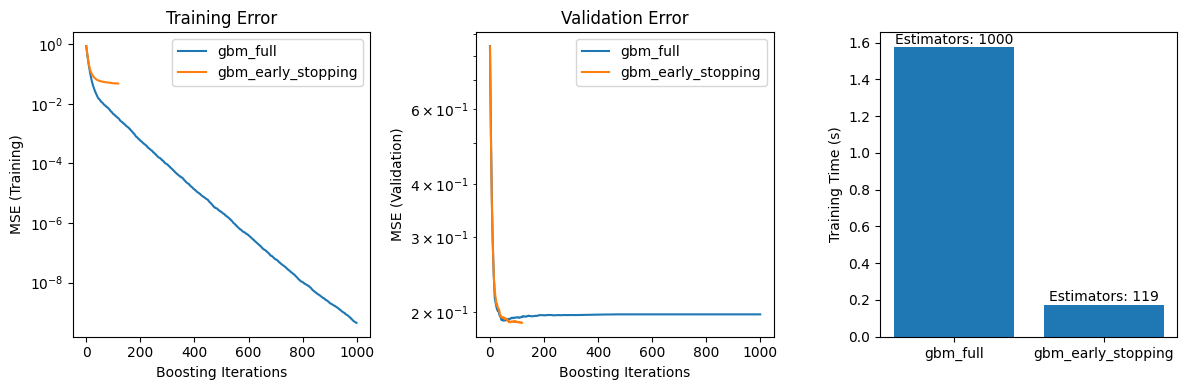

In [8]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))

axes[0].plot(train_errors_without, label="gbm_full")
axes[0].plot(train_errors_with, label="gbm_early_stopping")
axes[0].set_xlabel("Boosting Iterations")
axes[0].set_ylabel("MSE (Training)")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title("Training Error")

axes[1].plot(val_errors_without, label="gbm_full")
axes[1].plot(val_errors_with, label="gbm_early_stopping")
axes[1].set_xlabel("Boosting Iterations")
axes[1].set_ylabel("MSE (Validation)")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].set_title("Validation Error")

training_times = [training_time_full, training_time_early_stopping]
labels = ["gbm_full", "gbm_early_stopping"]
bars = axes[2].bar(labels, training_times)
axes[2].set_ylabel("Training Time (s)")

for bar, n_estimators in zip(bars, [n_estimators_full, estimators_early_stopping]):
    height = bar.get_height()
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.001,
        f"Estimators: {n_estimators}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()